In [8]:
import torch 

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA GPU:", torch.cuda.get_device_name(0))

elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple MPS")

else:
    device = torch.device("cpu")
    print("Using CPU")
    
    
from models import PrimeNet
from models import PrimeCNN
from models import PrimeTransformer
from dataset import PrimeDataset
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, auc
from sklearn.calibration import calibration_curve
from pathlib import Path

BASE_DIR = Path("E:/Python/prime_number_project")

DATA_PATH = BASE_DIR / "datasets" / "test_dataset.csv"
M_R_DIR = BASE_DIR / "models_results"

Using CPU


In [9]:
dataset_bin = PrimeDataset(DATA_PATH, mode= "binary", model_type= "mlp")
dataset_cnn = PrimeDataset(DATA_PATH, mode= "binary", model_type= "cnn")
dataset_transformer = PrimeDataset(DATA_PATH, mode= "binary", model_type= "transformer")
dataset_bin_mod = PrimeDataset(DATA_PATH, mode= "binary_mod", model_type= "mlp")
dataset_mod = PrimeDataset(DATA_PATH, mode= "mod", model_type= "mlp")

loader_bin = DataLoader(dataset_bin, batch_size=256)
loader_cnn = DataLoader(dataset_cnn, batch_size=256)
loader_transformer = DataLoader(dataset_transformer, batch_size=256)
loader_bin_mod = DataLoader(dataset_bin_mod, batch_size=256)
loader_mod = DataLoader(dataset_mod, batch_size=256)

In [10]:
bin_checkpoint = torch.load(M_R_DIR / "MLP_binary_only/MLP_binary_only.pt", map_location=device)
cnn_checkpoint = torch.load(M_R_DIR / "cnn_binary_only/cnn_binary_only.pt", map_location=device)
transformer_checkpoint = torch.load(M_R_DIR / "transformer_binary_only/transformer_binary_only.pt", map_location=device)
bin_mod_checkpoint = torch.load(M_R_DIR / "MLP_binary_mods/MLP_binary_mods.pt", map_location=device)
mod_checkpoint = torch.load(M_R_DIR / "MLP_mods_only/MLP_mods_only.pt", map_location=device)

C:\Users\User\AppData\Local\Temp\ipykernel_22920\3404319254.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  bin_checkpoint = torch.load(M_R_DIR / "MLP_binary_only/MLP_bi

In [11]:
print("Binary shape:", dataset_bin.binary.shape)
print("Binary:", dataset_bin.binary.shape[1])
print("CNN   :", dataset_cnn.binary.shape[1])
print("TRF   :", dataset_transformer.binary.shape[1])
print("Bin+Mod:", dataset_bin_mod.binary.shape[1])
print("Mod only (no binary):", dataset_mod.mods.shape[1])
print(len(bin(1250000)[2:]))

Binary shape: (500000, 21)
Binary: 21
CNN   : 21
TRF   : 21
Bin+Mod: 21
Mod only (no binary): 11
21


In [12]:
model_bin = PrimeNet(bin_checkpoint["input_dim"])
model_bin.load_state_dict(bin_checkpoint["model_state"])
model_bin.to(device)
model_bin.eval()

model_cnn = PrimeCNN(cnn_checkpoint["input_length"])
model_cnn.load_state_dict(cnn_checkpoint["model_state"])
model_cnn.to(device)
model_cnn.eval()

model_transformer = PrimeTransformer(transformer_checkpoint["input_length"])
model_transformer.load_state_dict(transformer_checkpoint["model_state"])
model_transformer.to(device)
model_transformer.eval()

model_bin_mod = PrimeNet(bin_mod_checkpoint["input_dim"])
model_bin_mod.load_state_dict(bin_mod_checkpoint["model_state"])
model_bin_mod.to(device)
model_bin_mod.eval()

model_mod = PrimeNet(mod_checkpoint["input_dim"])
model_mod.load_state_dict(mod_checkpoint["model_state"])
model_mod.to(device)
model_mod.eval()        

c:\Users\User\anaconda3\Lib\site-packages\torch\nn\modules\transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


PrimeNet(
  (net): Sequential(
    (0): Linear(in_features=11, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
    (10): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [13]:
def get_probs(model, loader):
    
    all_probs = []
    
    with torch.no_grad():
        for x, _ in loader:
            
            x = x.to(device)
            outputs = model(x)
            probs = torch.sigmoid(outputs)
            
            all_probs.extend(probs.cpu().numpy().flatten())
    
    return np.array(all_probs)

In [14]:
labels = dataset_bin.labels  

probs_bin     = get_probs(model_bin, loader_bin)
probs_cnn     = get_probs(model_cnn, loader_cnn)
probs_trf     = get_probs(model_transformer, loader_transformer)
probs_bin_mod = get_probs(model_bin_mod, loader_bin_mod)
probs_mod     = get_probs(model_mod, loader_mod)

def compute_roc(probs, labels):
    fpr, tpr, _ = roc_curve(labels, probs)
    auc = roc_auc_score(labels, probs)
    
    fpr_safe = np.clip(fpr, 1e-6, None)
    bkg_rej = 1 / fpr_safe
    
    return tpr, bkg_rej, auc

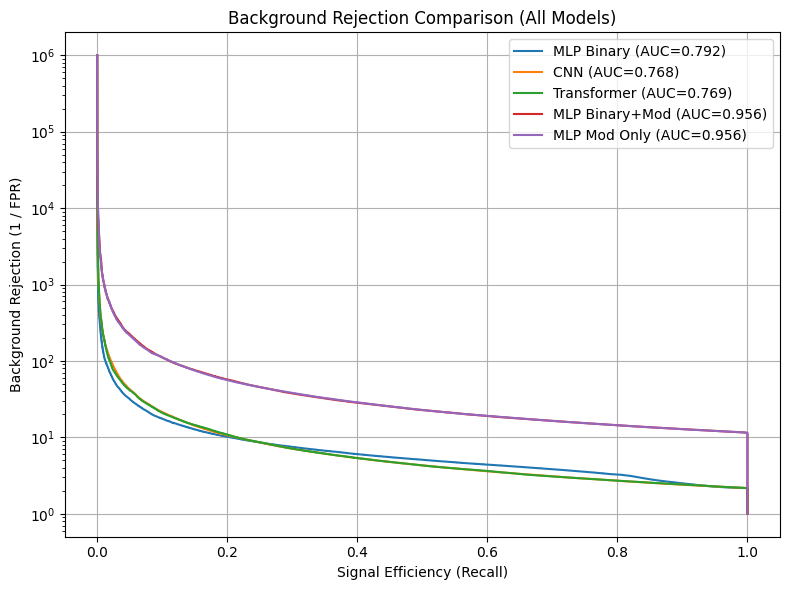

In [15]:
tpr_bin, bkg_bin, auc_bin = compute_roc(probs_bin, labels)
tpr_cnn, bkg_cnn, auc_cnn = compute_roc(probs_cnn, labels)
tpr_trf, bkg_trf, auc_trf = compute_roc(probs_trf, labels)
tpr_bin_mod, bkg_bin_mod, auc_bin_mod = compute_roc(probs_bin_mod, labels)
tpr_mod, bkg_mod, auc_mod = compute_roc(probs_mod, labels)

plt.figure(figsize=(8,6))

plt.plot(tpr_bin, bkg_bin, label=f"MLP Binary (AUC={auc_bin:.3f})")
plt.plot(tpr_cnn, bkg_cnn, label=f"CNN (AUC={auc_cnn:.3f})")
plt.plot(tpr_trf, bkg_trf, label=f"Transformer (AUC={auc_trf:.3f})")
plt.plot(tpr_bin_mod, bkg_bin_mod, label=f"MLP Binary+Mod (AUC={auc_bin_mod:.3f})")
plt.plot(tpr_mod, bkg_mod, label=f"MLP Mod Only (AUC={auc_mod:.3f})")

plt.xlabel("Signal Efficiency (Recall)")
plt.ylabel("Background Rejection (1 / FPR)")
plt.title("Background Rejection Comparison (All Models)")

plt.yscale("log")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(M_R_DIR / "comparison/all_models_roc_comparison.png")
plt.show()

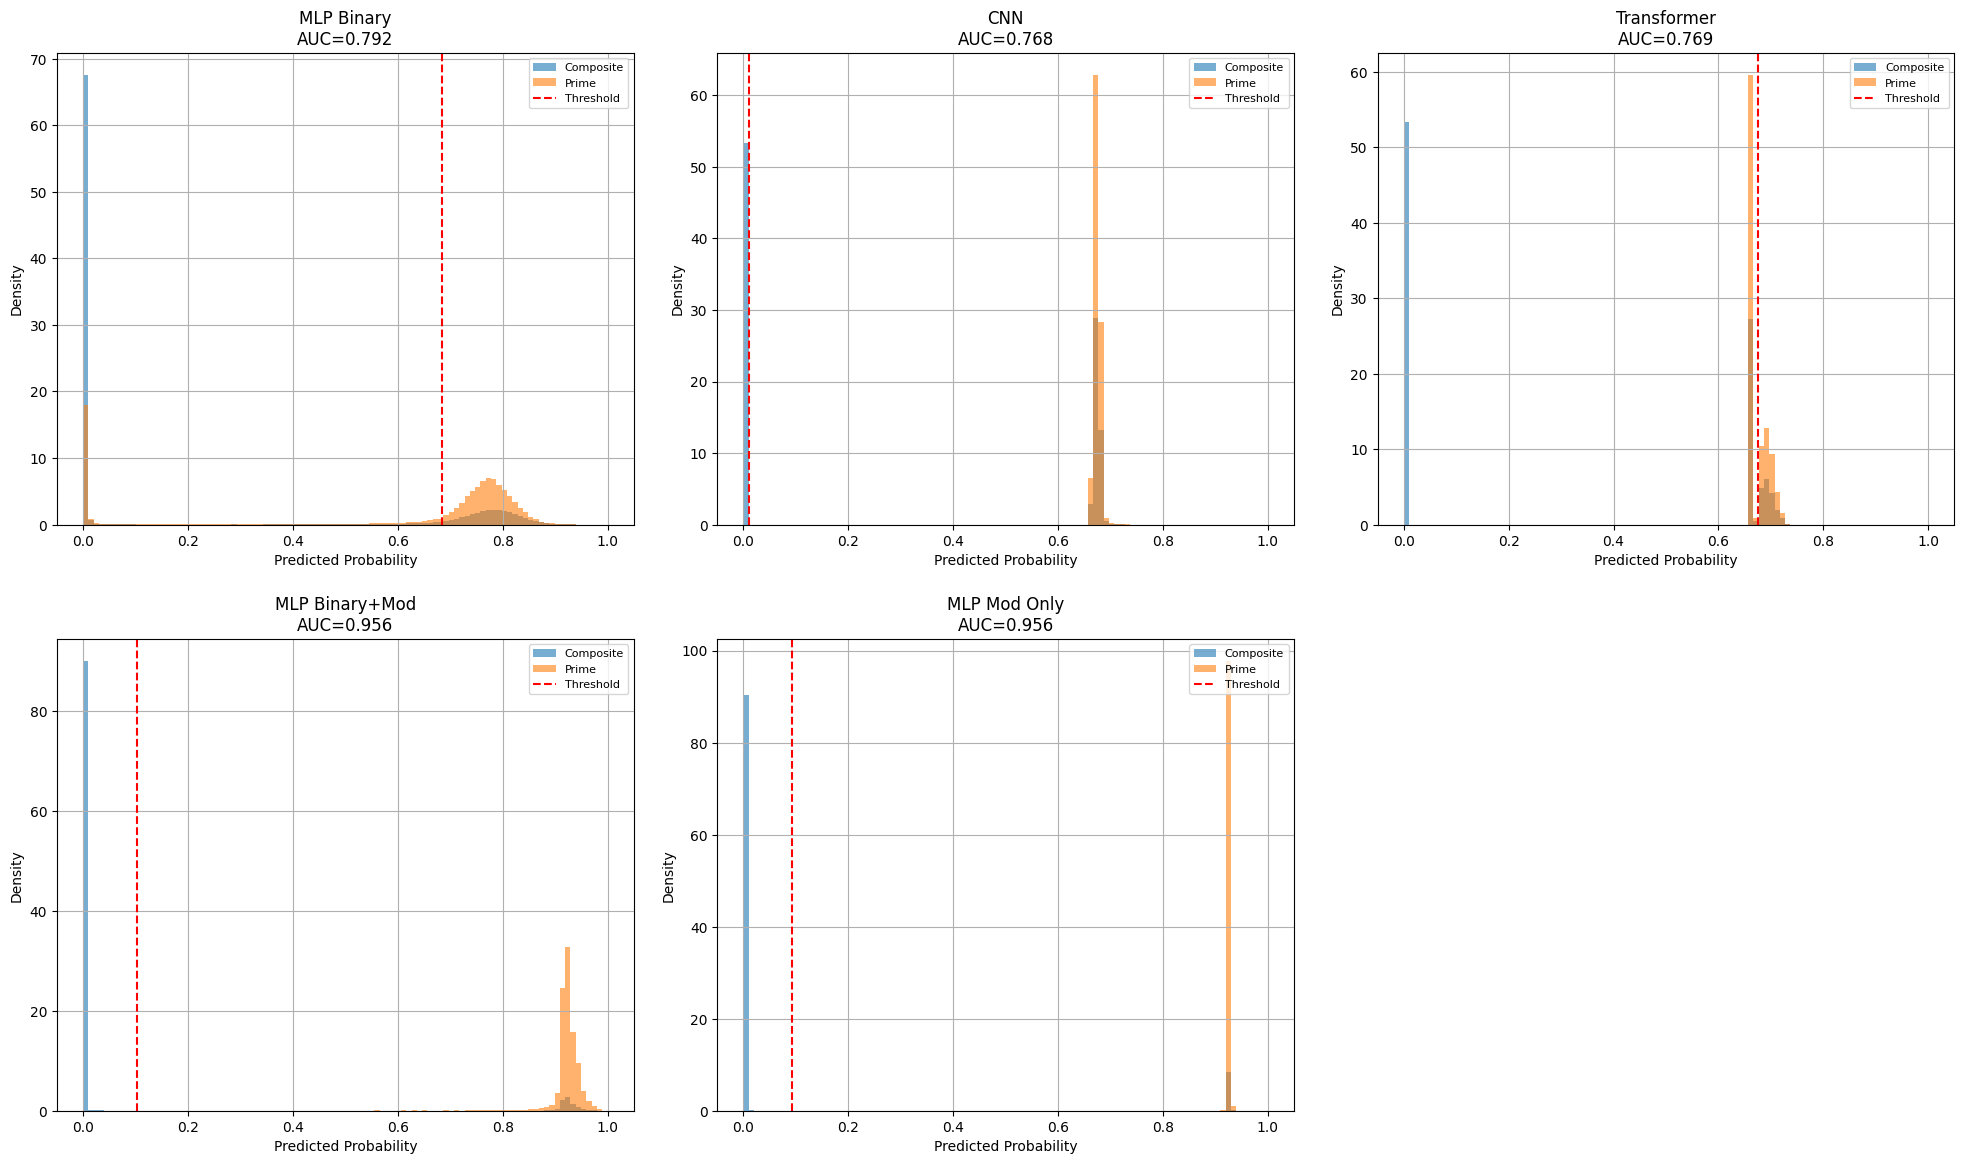

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(20,12))
axes = axes.flatten()

bins = np.linspace(0, 1, 100)

models = {
    "MLP Binary": probs_bin,
    "CNN": probs_cnn,
    "Transformer": probs_trf,
    "MLP Binary+Mod": probs_bin_mod,
    "MLP Mod Only": probs_mod
}

thresholds = {
    "MLP Binary": 0.684,
    "CNN": 0.01,
    "Transformer": 0.675,
    "MLP Binary+Mod": 0.103,
    "MLP Mod Only": 0.093
}

auc_values = {
    "MLP Binary": auc_bin,
    "CNN": auc_cnn,
    "Transformer": auc_trf,
    "MLP Binary+Mod": auc_bin_mod,
    "MLP Mod Only": auc_mod
}

for ax, (name, probs) in zip(axes, models.items()):
    
    prime_probs = probs[labels == 1]
    comp_probs  = probs[labels == 0]
    
    ax.hist(comp_probs, bins=bins, alpha=0.6, color='tab:blue', label="Composite", density=True)
    ax.hist(prime_probs, bins=bins, alpha=0.6, color='tab:orange', label="Prime", density=True)
    
    ax.axvline(thresholds[name], color='red', linestyle='--', label='Threshold')
    
    ax.set_title(f"{name}\nAUC={auc_values[name]:.3f}")
    ax.set_xlabel("Predicted Probability")
    ax.set_ylabel("Density")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True)

for i in range(len(models), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout(pad=2.0)
plt.savefig(M_R_DIR / "comparison/all_models_probability_distributions.png")
plt.show()

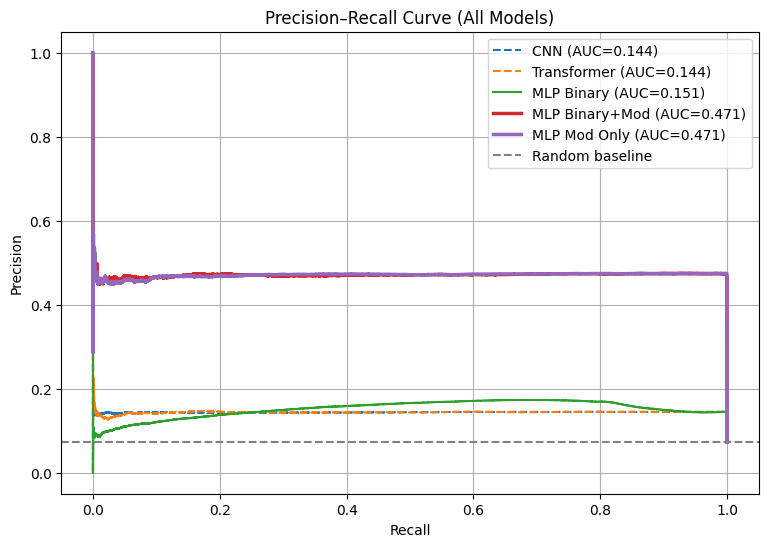

In [17]:
prec_bin, rec_bin, _ = precision_recall_curve(labels, probs_bin)
prec_cnn, rec_cnn, _ = precision_recall_curve(labels, probs_cnn)
prec_trf, rec_trf, _ = precision_recall_curve(labels, probs_trf)
prec_bin_mod, rec_bin_mod, _ = precision_recall_curve(labels, probs_bin_mod)
prec_mod, rec_mod, _ = precision_recall_curve(labels, probs_mod)

pr_auc_bin = auc(rec_bin, prec_bin)
pr_auc_cnn = auc(rec_cnn, prec_cnn)
pr_auc_trf = auc(rec_trf, prec_trf)
pr_auc_bin_mod = auc(rec_bin_mod, prec_bin_mod)
pr_auc_mod = auc(rec_mod, prec_mod)

baseline = np.mean(labels)

plt.figure(figsize=(9,6))

plt.plot(rec_cnn, prec_cnn, linestyle="--", label=f"CNN (AUC={pr_auc_cnn:.3f})")
plt.plot(rec_trf, prec_trf, linestyle="--", label=f"Transformer (AUC={pr_auc_trf:.3f})")

plt.plot(rec_bin, prec_bin, label=f"MLP Binary (AUC={pr_auc_bin:.3f})")

plt.plot(rec_bin_mod, prec_bin_mod, linewidth=2.5, label=f"MLP Binary+Mod (AUC={pr_auc_bin_mod:.3f})")
plt.plot(rec_mod, prec_mod, linewidth=2.5, label=f"MLP Mod Only (AUC={pr_auc_mod:.3f})")

plt.axhline(baseline, linestyle="--", color="gray", label="Random baseline")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (All Models)")

plt.legend()
plt.grid(True)
plt.savefig(M_R_DIR / "comparison/all_models_pr_comparison.png")
plt.show()

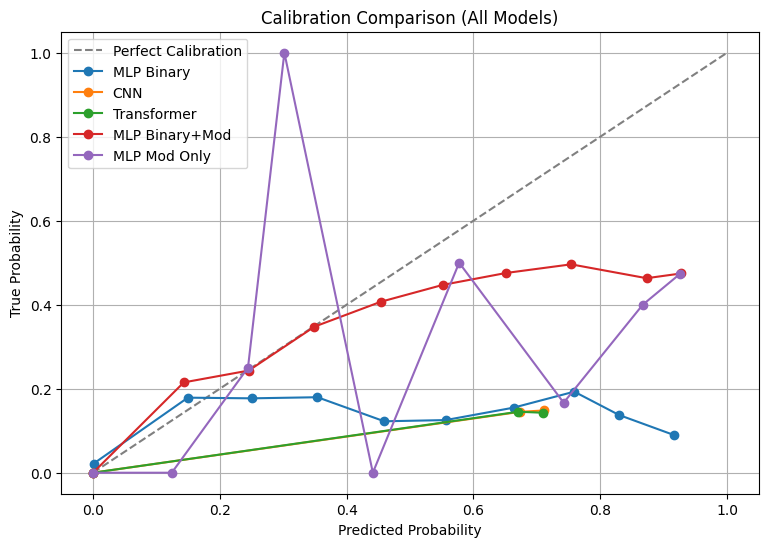

In [18]:
plt.figure(figsize=(9,6))

plt.plot([0,1], [0,1], '--', color='gray', label="Perfect Calibration")

models = [
    ("MLP Binary", probs_bin),
    ("CNN", probs_cnn),
    ("Transformer", probs_trf),
    ("MLP Binary+Mod", probs_bin_mod),
    ("MLP Mod Only", probs_mod)
]

for name, probs in models:
    
    prob_true, prob_pred = calibration_curve(labels, probs, n_bins=10)
    
    order = np.argsort(prob_pred)
    prob_pred = np.array(prob_pred)[order]
    prob_true = np.array(prob_true)[order]
    
    plt.plot(prob_pred, prob_true, marker='o', label=name)

plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.title("Calibration Comparison (All Models)")

plt.legend()
plt.grid(True)
plt.savefig(M_R_DIR / "comparison/all_models_calibration_comparison.png")
plt.show()

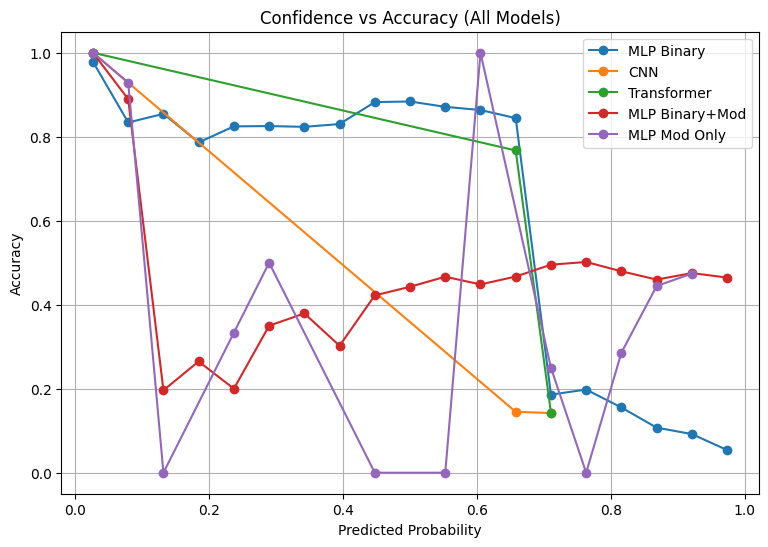

In [19]:
plt.figure(figsize=(9,6))

bins = np.linspace(0, 1, 20)

for name, probs in models:
    
    bin_centers = []
    accuracy = []
    
    for i in range(len(bins)-1):
        mask = (probs >= bins[i]) & (probs < bins[i+1])
        
        if np.sum(mask) > 0:
            preds = (probs[mask] > thresholds[name]).astype(int)
            acc = np.mean(preds == labels[mask])
            
            bin_centers.append((bins[i] + bins[i+1]) / 2)
            accuracy.append(acc)
    
    plt.plot(bin_centers, accuracy, marker='o', label=name)

plt.xlabel("Predicted Probability")
plt.ylabel("Accuracy")
plt.title("Confidence vs Accuracy (All Models)")

plt.legend()
plt.grid(True)
plt.savefig(M_R_DIR / "comparison/all_models_confidence_accuracy_comparison.png")
plt.show()